In [2]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

from environments import CorridorEnvTerminalReward, CorridorEnvTimePenalty
from utils import annotated_heatmap, analytical_policy_evaluation, epsilon_greedy_policy
from plotting import plot_policy

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

MAX_EPISODE_DURATION = 100

In [62]:
class PolicyNetwork(nn.Module):
    def __init__(self, n_states, n_hidden, n_actions):
        super(PolicyNetwork, self).__init__()
        # Using an Embedding or One-Hot input for discrete states
        self.affine = nn.Linear(n_states, n_hidden)
        self.action_head = nn.Linear(n_hidden, n_actions)

    def forward(self, x):
        # x is state index; convert to one-hot for the network
        x = F.one_hot(torch.tensor(x), num_classes=env.nS).float()
        x = F.relu(self.affine(x))
        action_prob = F.softmax(self.action_head(x), dim=-1)
        return action_prob
        
class DQN(nn.Module):
    def __init__(self, n_states, n_hidden):
        super(DQN, self).__init__()
        # Using an Embedding or One-Hot input for discrete states
        self.affine = nn.Linear(n_states, n_hidden)
        self.action_head = nn.Linear(n_hidden, 1)

    def forward(self, x):
        # x is state index; convert to one-hot for the network
        x = F.one_hot(torch.tensor(x), num_classes=env.nS).float()
        x = F.relu(self.affine(x))
        return self.action_head(x)

In [65]:
def actor_critic(env, episodes=100, gamma=0.99, lr=1e-2):
    n_hidden = 32

    policy = PolicyNetwork(env.nS, n_hidden, env.nA)
    policy_optimizer = optim.Adam(policy.parameters(), lr=lr)

    dqn = DQN(env.nS, n_hidden)
    value_optimizer = optim.Adam(dqn.parameters(), lr=lr)

    rewards_list = []
    
    for ep in range(episodes):
        state = env.reset()
        done = False
        steps_count = 0
        rewards = []
        
        # 1. Collect Episode
        while not done:
            probs = policy(state)
            m = torch.distributions.Categorical(probs)
            action = m.sample()
            log_prob = m.log_prob(action)
            
            # Sample from the environment model (CorridorEnvTerminalReward logic)
            transitions = env.step(state, action.item())
            # transitions = [(p1, s_, r, d), (p2, s, r, d)]
            idx = np.random.choice(len(transitions), p=[t[0] for t in transitions])
            _, next_state, reward, done = transitions[idx]
            rewards.append(reward)

            # 1. Get Critic values
            current_value = dqn(state)
            next_value = dqn(next_state)
            
            target = reward + gamma * next_value.detach() * (1 - int(done))

            # Loss (unsqueezing expected_q to [Batch, 1] to match current_q)
            value_loss = F.mse_loss(current_value.view(-1), target.view(-1)) # View is needed to reshape the tensors and make sure they are both 1D
            value_optimizer.zero_grad()
            value_loss.backward()
            value_optimizer.step()

            # 3 Compute Advantage
            advantage = target - current_value.detach()
            # print("Adv",advantage, - log_prob * advantage)
            
            policy_optimizer.zero_grad()
            policy_loss = - log_prob * advantage
            policy_loss.backward()
            policy_optimizer.step()

            state = next_state
            steps_count += 1
            
        if ep % 50 == 0:
                print(f"Episode {ep} | Total Reward: {sum(rewards)}")
            
        rewards_list.append(sum(rewards))

    return policy, rewards_list

In [66]:
env = CorridorEnvTimePenalty(n_states=10, is_slippery=True)
trained_policy, rewards = actor_critic(env)

Episode 0 | Total Reward: -98
Episode 50 | Total Reward: -5


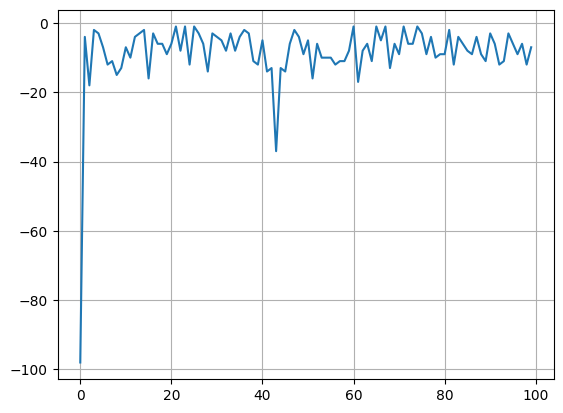

In [67]:
plt.grid()
plt.plot(rewards)

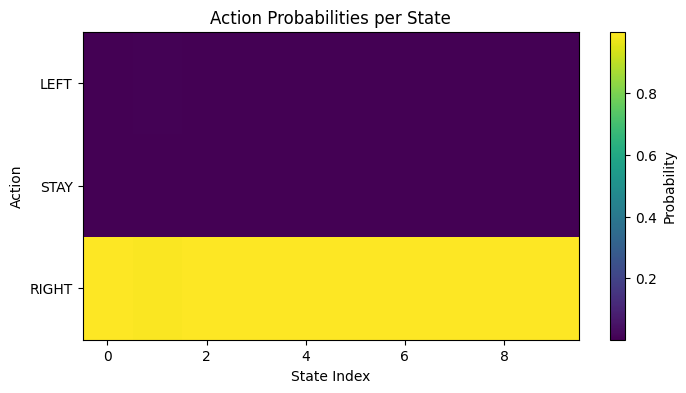

In [68]:
# Extract probabilities for each state
policy_probs = []
for s in range(env.nS):
    with torch.no_grad():
        probs = trained_policy(s).numpy()
    policy_probs.append(probs)
policy_probs = np.array(policy_probs)

# --- Plot 1: Heatmap ---
plt.figure(figsize=(8, 4))
plt.imshow(policy_probs.T, aspect='auto', cmap='viridis')
plt.colorbar(label='Probability')
plt.xlabel('State Index')
plt.ylabel('Action')
plt.yticks([0, 1, 2], ['LEFT', 'STAY', 'RIGHT'])
plt.title('Action Probabilities per State')
plt.show()

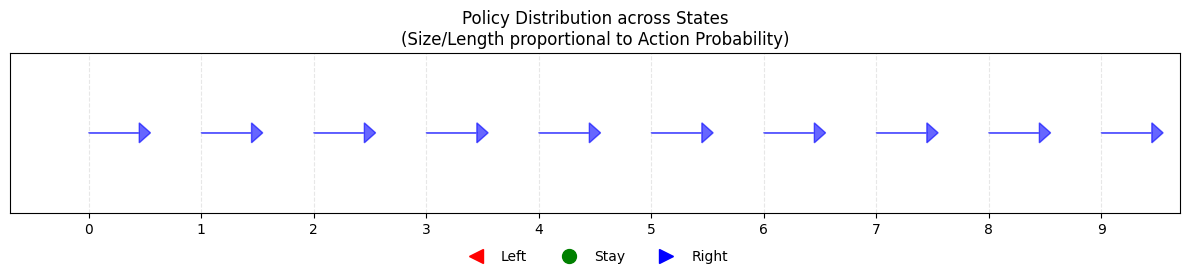

In [69]:
plot_policy(policy_probs)